# 🚲 Project 3: Bike Sharing Demand Predictor
### Dataset: Bike Sharing Demand Dataset (hour.csv / day.csv)
---

## 📋 Dataset Overview & Expected Target

| Feature | Description | Type |
|---------|-------------|------|
| `instant` | Row index | Drop |
| `dteday` | Date string | Parse → new features |
| `season` | 1=Spring, 2=Summer, 3=Fall, 4=Winter | Ordinal Categorical |
| `yr` | Year: 0=2011, 1=2012 | Binary Numerical |
| `mnth` | Month (1–12) | Cyclical Numerical |
| `hr` | Hour of day (0–23) | Cyclical Numerical |
| `holiday` | Whether day is a public holiday | Binary |
| `weekday` | Day of week (0=Sun … 6=Sat) | Cyclical Numerical |
| `workingday` | 1 if neither weekend nor holiday | Binary |
| `weathersit` | 1=Clear, 2=Mist, 3=Light rain, 4=Heavy rain | Ordinal |
| `temp` | Normalised temperature (÷41) | Numerical |
| `atemp` | Normalised "feels-like" temperature (÷50) | Numerical |
| `hum` | Normalised humidity (÷100) | Numerical |
| `windspeed` | Normalised wind speed (÷67) | Numerical |
| `casual` | Count of casual riders | ⚠️ DROP (leakage) |
| `registered` | Count of registered riders | ⚠️ DROP (leakage) |

> 🎯 **Target Variable → `cnt`** (total rentals = casual + registered)
> 📌 **Task Type → Regression (count prediction)**

> ⚠️ **Leakage Warning:** `casual` and `registered` are sub-components of `cnt`.
> Including them in `X` gives a perfect-but-meaningless model. **Always drop them.**

> 💡 **What makes this project different from the first two:** the rows are ordered in time,
> and several features are *circular*. Both facts change decisions you made on autopilot before —
> how you split, and how you encode. Those are the two things to get right here.

## 🧭 How to use this notebook

Every cell below is a **brief**, not a solution. Each one tells you:

- **Goal** — what this cell must produce when you're done
- **Hints** — which family of tools to reach for, and the trap to avoid
- **Check yourself** — how you'll know your output is right

No answer code is included on purpose. If you get stuck for more than ~10 minutes on a cell, look up the library docs first (`pandas`, `seaborn`, `scikit-learn` all have excellent ones), and only then ask for a nudge on that *specific* cell.

Variable names that later cells depend on are stated explicitly (e.g. `df`, `df_clean`, `X_train`). Stick to those names and the notebook stays coherent.

---
## ⚙️ Phase 1 — Environment & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)

warnings.filterwarnings("ignore")


TARGET = "cnt"
LEAKAGE_COLS = ["casual", "registered", "instant", "dteday"]

### 1.1 — Load the Dataset

In [2]:
FILE_PATH = "hour.csv"   

df = pd.read_csv(FILE_PATH)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


### 1.2 — Initial Inspection

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [6]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

### 2.1 — Target Variable Distribution

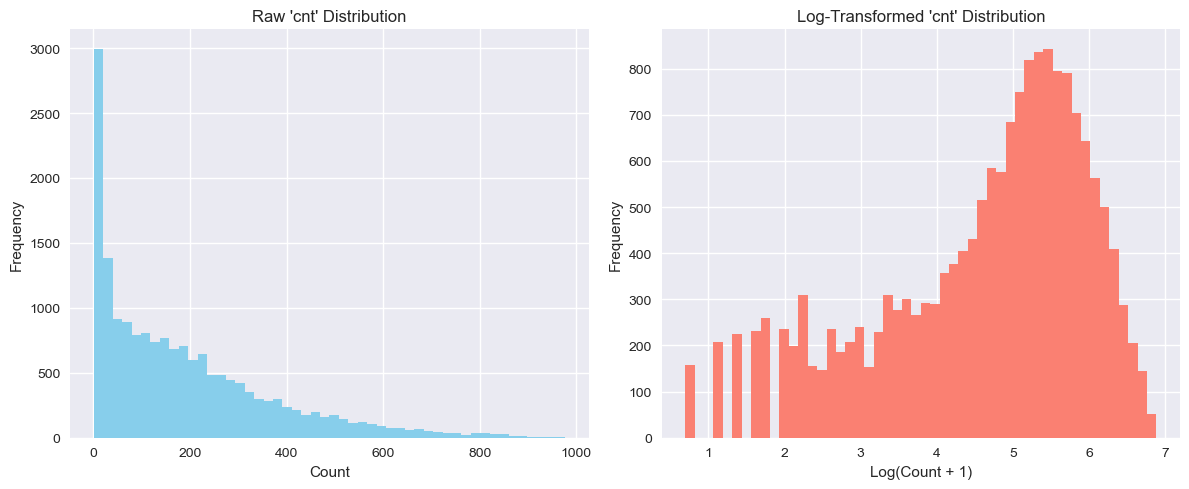

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df[TARGET], bins=50, color="skyblue")
axes[0].set_title("Raw 'cnt' Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df[TARGET]), bins=50, color="salmon")
axes[1].set_title("Log-Transformed 'cnt' Distribution")
axes[1].set_xlabel("Log(Count + 1)")
axes[1].set_ylabel("Frequency")

fig.tight_layout()
plt.show()

### 2.2 — Hourly Rental Pattern (The Pivotal Plot)

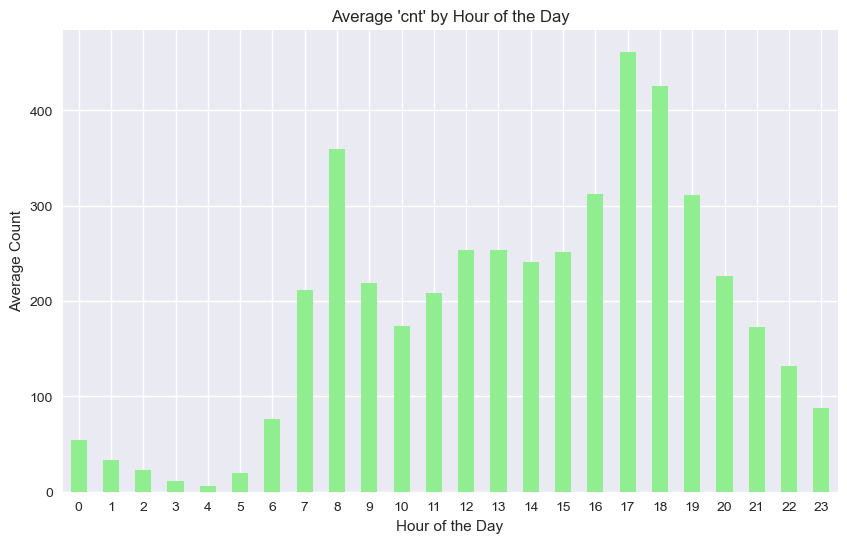

In [8]:
df.groupby("hr")[TARGET].mean().plot(kind="bar", color="lightgreen")
plt.title("Average 'cnt' by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.show()

### 2.3 — Seasonal and Monthly Patterns

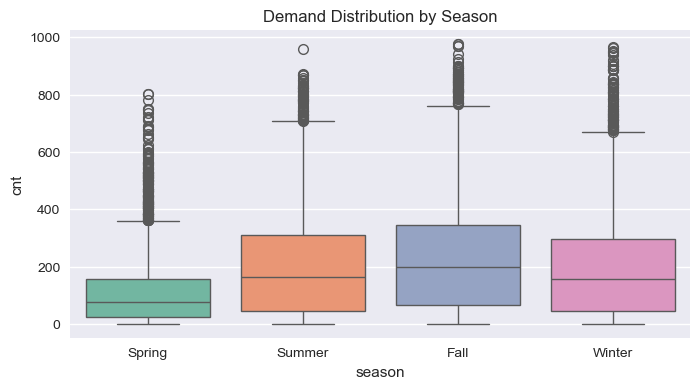

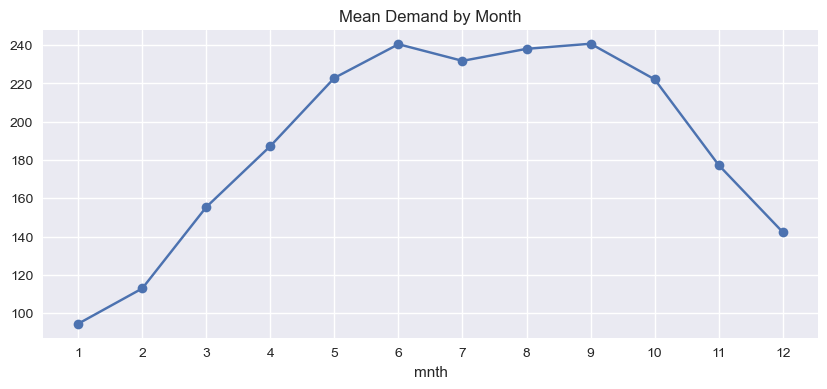

In [9]:
plt.figure(figsize=(8, 4))
ax = sns.boxplot(x="season", y=TARGET, data=df, palette="Set2")
ax.set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('Demand Distribution by Season')
plt.show()

plt.figure(figsize=(10, 4))
df.groupby('mnth')[TARGET].mean().plot(kind='line', marker='o')
plt.title('Mean Demand by Month')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

### 2.4 — Weekday vs Weekend vs Holiday

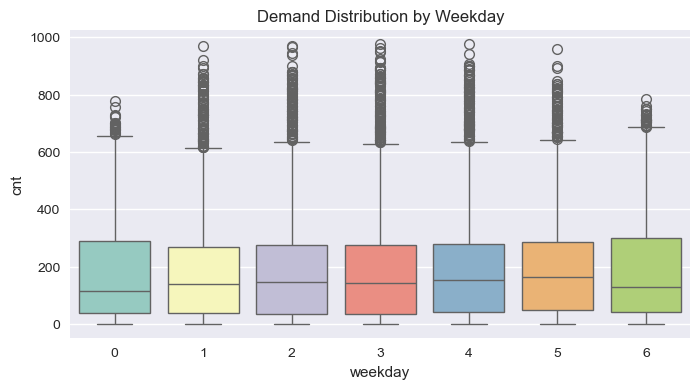

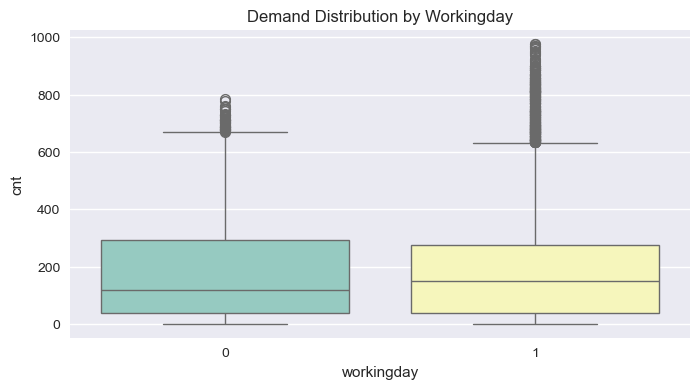

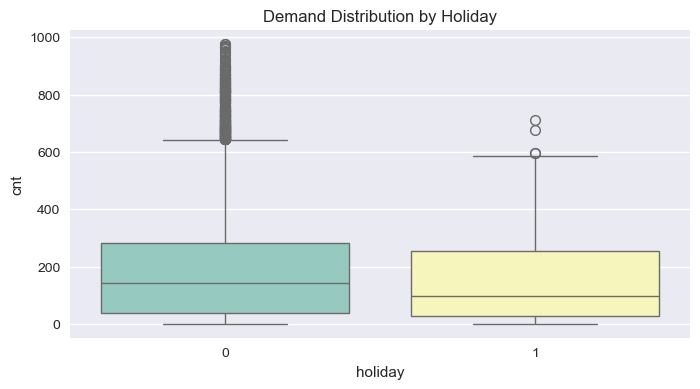

In [10]:
category = ["weekday", "workingday", "holiday"]
for col in category:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y=TARGET, data=df, palette="Set3")
    plt.title(f'Demand Distribution by {col.capitalize()}')
    plt.show()

### 2.5 — Weather Impact on Demand

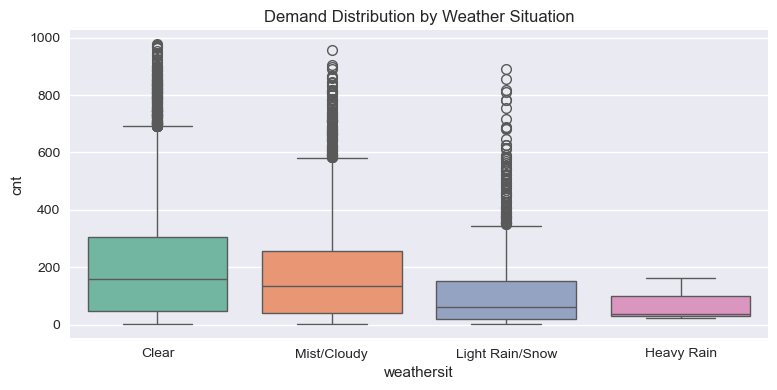

In [11]:
plt.figure(figsize=(9, 4))
sns.boxplot(x="weathersit", y="cnt", data=df, palette="Set2")
plt.xticks([0, 1, 2, 3], ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain'])
plt.title('Demand Distribution by Weather Situation')
plt.show()

### 2.6 — Temperature vs Ridership

Text(0, 0.5, 'Count')

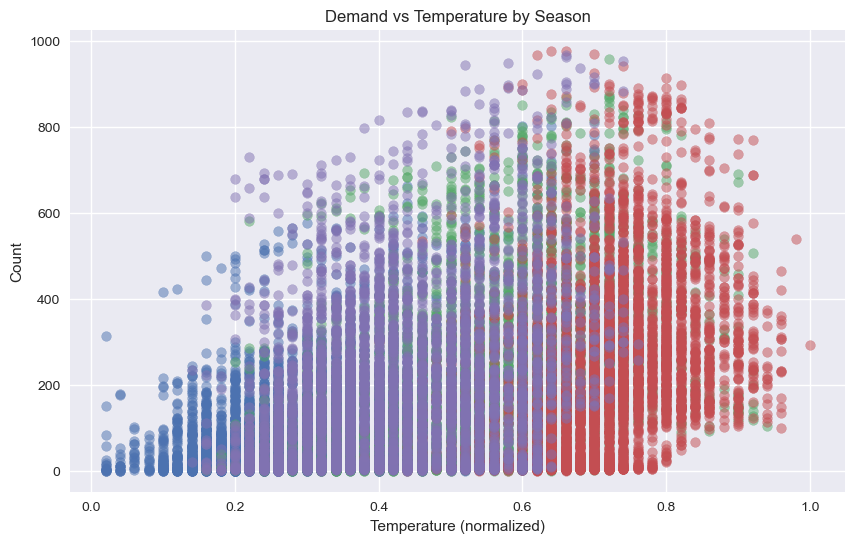

In [12]:
season = ['spring', 'summer', 'fall', 'winter']
for s in season:
    plt.scatter(df[df['season'] == season.index(s) + 1]['temp'], 
                df[df['season'] == season.index(s) + 1]['cnt'], 
                alpha=0.5, label=s.capitalize())
plt.title('Demand vs Temperature by Season')
plt.xlabel('Temperature (normalized)')
plt.ylabel('Count')

### 2.7 — Correlation Heatmap

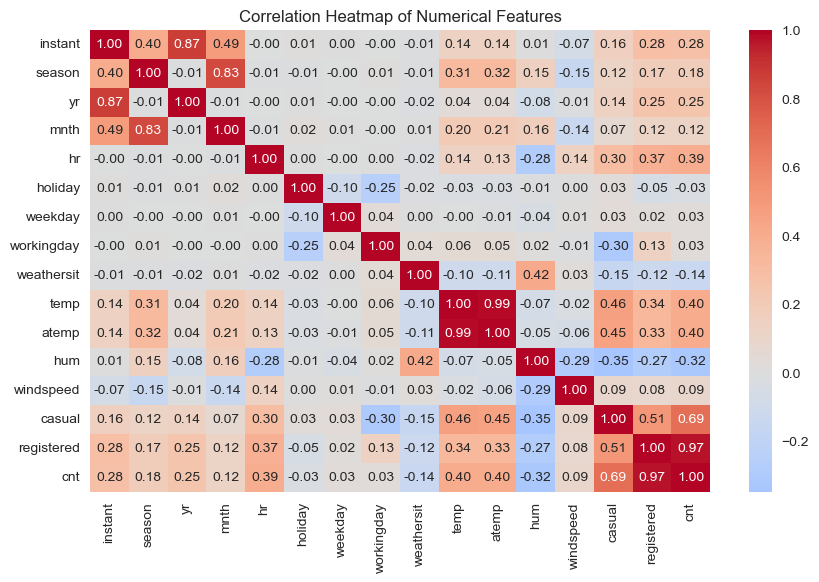

In [13]:
df.dtypes
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 2.8 — Hour × Weekday Demand Heatmap

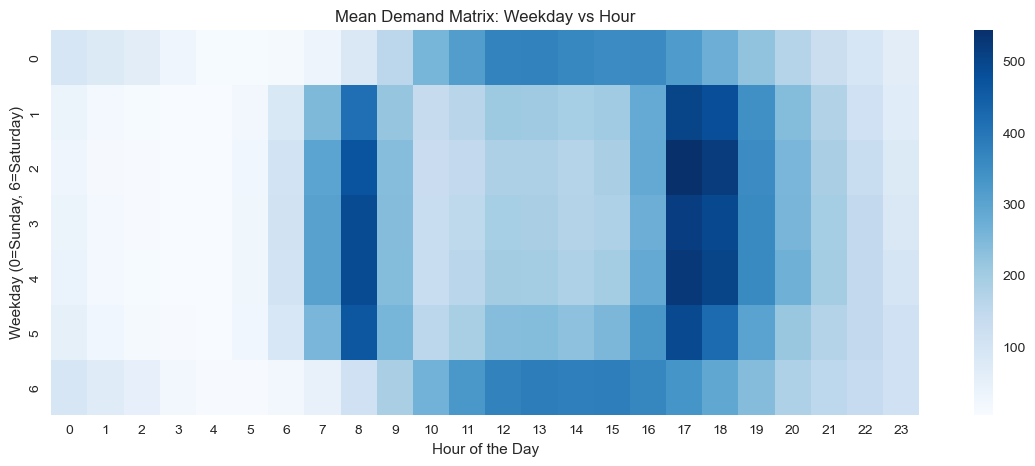

In [14]:
pivot_df = df.pivot_table(values='cnt', index='weekday', columns='hr', aggfunc='mean')
plt.figure(figsize=(14, 5))

sns.heatmap(pivot_df, cmap='Blues', annot=False)
plt.title('Mean Demand Matrix: Weekday vs Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Weekday (0=Sunday, 6=Saturday)')
plt.show()

### 2.9 — Year-over-Year Growth

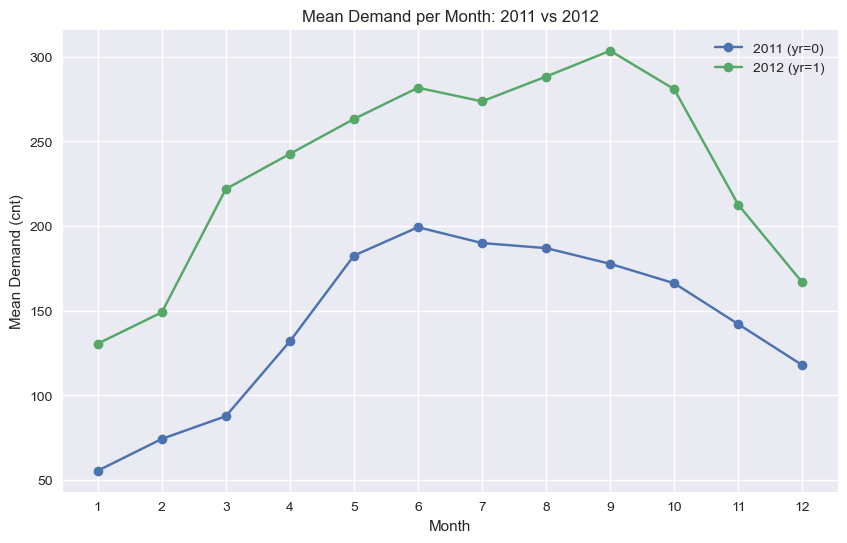

In [15]:
df[df['yr'] == 0].groupby('mnth')['cnt'].mean().plot(kind='line', marker='o', label='2011 (yr=0)')
df[df['yr'] == 1].groupby('mnth')['cnt'].mean().plot(kind='line', marker='o', label='2012 (yr=1)')

plt.title('Mean Demand per Month: 2011 vs 2012')
plt.xlabel('Month')
plt.ylabel('Mean Demand (cnt)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

---
## 🔧 Phase 3 — Data Preprocessing & Feature Engineering

In [16]:
df_clean = df.copy()

### 3.1 — Drop Leakage & Irrelevant Columns

In [17]:
df_clean.head()
df_clean.drop(columns= ["casual", "registered", "instant", "dteday"], inplace=True)

### 3.2 — Handle Missing Values

In [18]:
df_clean.isnull().sum()

season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

### 3.3 — Cyclical Feature Encoding

Hour (0–23), month (1–12), and weekday (0–6) are **circular** — hour 23 and hour 0 are one hour apart, but as raw integers they sit at opposite ends of the range.

**Sine/cosine encoding** maps each cycle onto a unit circle, so that the last value and the first value land next to each other.

| Feature | Period |
|---------|--------|
| `hr` | 24 |
| `mnth` | 12 |
| `weekday` | 7 |

The formula for one feature `v` with period `p` is a pair of columns: the sine and the cosine of `2π · v / p`.

In [19]:
for col, period in [('hr', 24), ('mnth', 12), ('weekday', 7)]:
    df_clean[f'{col}_sin'] = np.sin(2 * np.pi * df_clean[col] / period)
    df_clean[f'{col}_cos'] = np.cos(2 * np.pi * df_clean[col] / period)

print(df_clean.shape)

(17379, 19)


### 3.4 — Additional Feature Engineering

In [20]:
df_clean['rush_hour'] = df_clean['hr'].isin([7, 8, 9, 16, 17, 18]).astype(int)

df_clean['comfort_index'] = df_clean['temp'] * (1 - df_clean['hum'])
print(df_clean.shape)
df_clean[['hr', 'rush_hour', 'temp', 'hum', 'comfort_index']].head()

(17379, 21)


,hr,rush_hour,temp,hum,comfort_index
0,0,0,0.24,0.81,0.0456
1,1,0,0.22,0.80,0.0440
2,2,0,0.22,0.80,0.0440
3,3,0,0.24,0.75,0.0600
4,4,0,0.24,0.75,0.0600


---
## 🤖 Phase 4 — Model Training & Evaluation

### 4.1 — X / y Split

In [21]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(X.columns.tolist())

X shape: (17379, 20), y shape: (17379,)
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'rush_hour', 'comfort_index']


### 4.2 — Train / Test Split



In [22]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

print(f"y_train mean: {y_train.mean():.2f}")
print(f"y_test mean:  {y_test.mean():.2f}")

X_train: (13903, 20), X_test: (3476, 20)
y_train: (13903,), y_test: (3476,)
y_train mean: 174.64
y_test mean:  248.75


### 4.3 — Baseline: Linear Regression

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Predictions:", lr_preds[:5])
print("Min prediction:", lr_preds.min())

Predictions: [308.48868276 325.78877218 354.40444002 375.42026751 430.36551452]
Min prediction: -8.883763324781796


### 4.4 — Ridge Regression

In [24]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)
print("Ridge Predictions:", ridge_preds[:5])

Ridge Predictions: [308.46840466 325.7778499  354.40509766 375.41693931 430.3233359 ]


### 4.5 — Random Forest Regressor

In [25]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest Predictions:", rf_preds[:5])

Random Forest Predictions: [254.053334   254.053334   254.053334   261.7795027  345.14525598]


### 4.6 — Gradient Boosting Regressor

In [26]:
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
print("Gradient Boosting Predictions:", gb_preds[:5])

Gradient Boosting Predictions: [268.80140199 267.74254224 267.01893385 280.83041086 400.1972485 ]


### 4.7 — Evaluation Helper Function

In [27]:
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_c = np.maximum(0, y_true)
    y_pred_c = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true_c), np.log1p(y_pred_c)))

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "RMSLE": rmsle,
        "R2": r2
    }

results = []

models = {
    "Linear Regression": (LinearRegression(), X_train_scaled, X_test_scaled),
    "Ridge Regression": (Ridge(alpha=1.0), X_train_scaled, X_test_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test)
}

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    results.append(evaluate_model(name, y_test, preds))

### 4.8 — Model Comparison Table

In [28]:
df_results = pd.DataFrame(results).set_index("Model").sort_values("RMSLE", ascending=True)
df_results

,MSE,RMSE,MAE,RMSLE,R2
Model,,,,,
Random Forest,5220.829572,72.255308,47.379112,0.401032,0.892605
Gradient Boosting,9940.540392,99.702259,67.863681,0.615161,0.795519
Ridge Regression,21562.116740,146.840447,106.188448,1.046221,0.556459
Linear Regression,21561.535710,146.838468,106.190223,1.046236,0.556471


### 4.9 — Feature Importance (Random Forest)

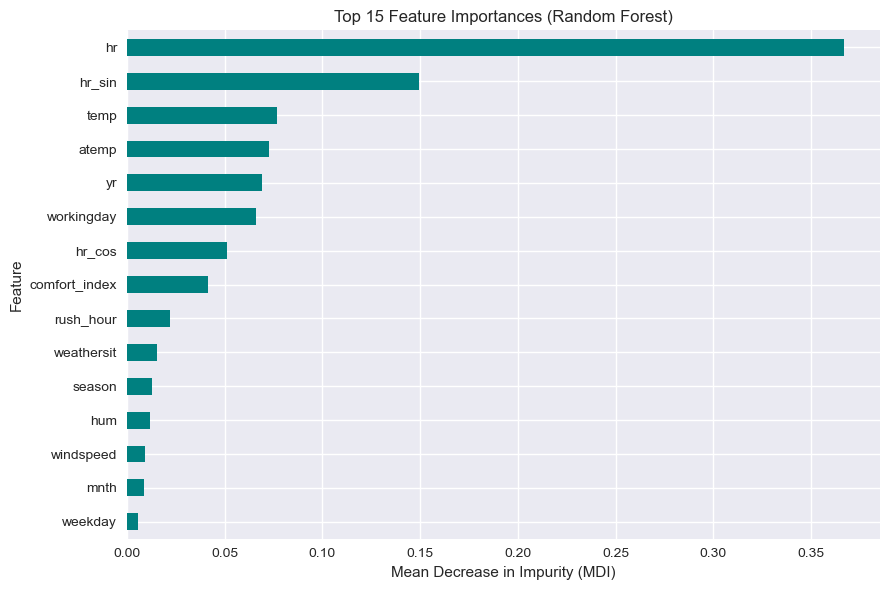

In [29]:
rf_model = models["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

top_15 = importances.sort_values(ascending=True).tail(15)

top_15.plot(kind="barh", figsize=(9, 6), color="teal")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Mean Decrease in Impurity (MDI)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 4.10 — Actual vs Predicted Over Time

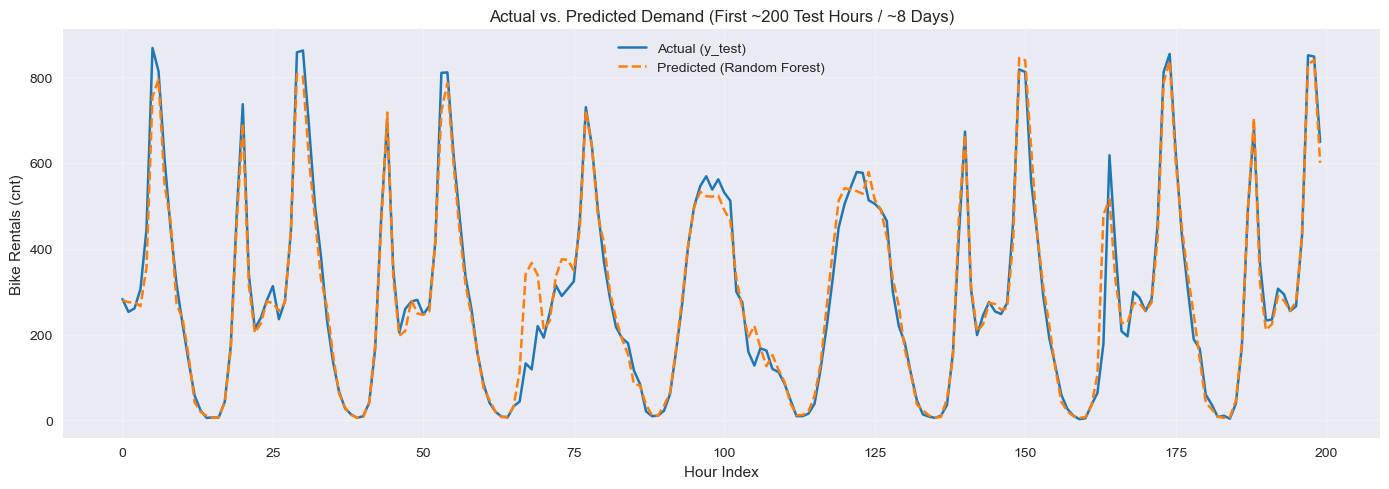

In [30]:
n_samples = 200

y_test_subset = y_test.iloc[:n_samples].values
y_pred_subset = models["Random Forest"][0].predict(X_test)[:n_samples]

plt.figure(figsize=(14, 5))
plt.plot(y_test_subset, label="Actual (y_test)", color="#1f77b4", linewidth=1.8)
plt.plot(y_pred_subset, label="Predicted (Random Forest)", color="#ff7f0e", linestyle="--", linewidth=1.8)

plt.title("Actual vs. Predicted Demand (First ~200 Test Hours / ~8 Days)")
plt.xlabel("Hour Index")
plt.ylabel("Bike Rentals (cnt)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.11 — Mean Absolute Error by Hour of Day

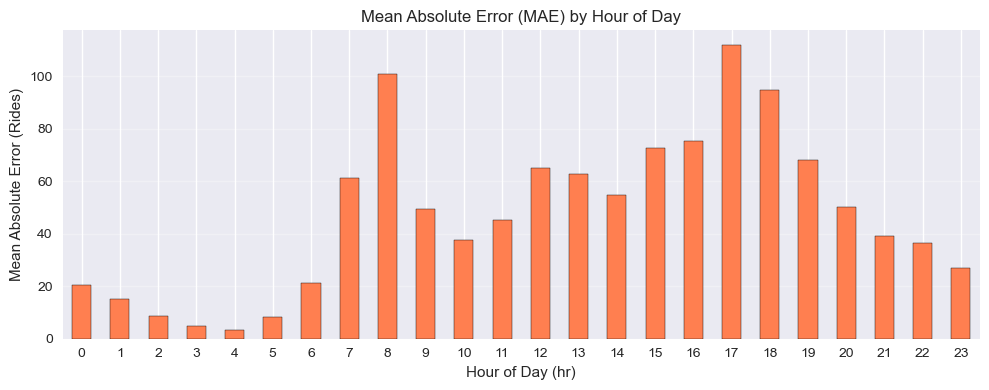

In [31]:
df_hourly = X_test.copy()
if "hr" not in df_hourly.columns:
    df_hourly["hr"] = df.loc[X_test.index, "hr"]
df_hourly["actual"] = y_test.values
df_hourly["pred"] = models["Random Forest"][0].predict(X_test)
df_hourly["abs_error"] = (df_hourly["actual"] - df_hourly["pred"]).abs()

hourly_metrics = df_hourly.groupby("hr").agg(
    mae=("abs_error", "mean"),
    mean_actual=("actual", "mean")
)
hourly_metrics["normalized_error"] = hourly_metrics["mae"] / hourly_metrics["mean_actual"]

plt.figure(figsize=(10, 4))
hourly_metrics["mae"].plot(kind="bar", color="coral", edgecolor="black")
plt.title("Mean Absolute Error (MAE) by Hour of Day")
plt.xlabel("Hour of Day (hr)")
plt.ylabel("Mean Absolute Error (Rides)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 4.12 — Cross-Validation

In [32]:
rf_cv = RandomForestRegressor(n_estimators=100, random_state=42)

scores_kfold = cross_val_score(rf_cv, X, y, cv=5, scoring="r2")

tscv = TimeSeriesSplit(n_splits=5)
scores_tscv = cross_val_score(rf_cv, X, y, cv=tscv, scoring="r2")

print(f"Standard 5-Fold R²:   {scores_kfold.mean():.4f} ± {scores_kfold.std():.4f}")
print(f"TimeSeriesSplit R²:   {scores_tscv.mean():.4f} ± {scores_tscv.std():.4f}")

Standard 5-Fold R²:   0.8021 ± 0.0938
TimeSeriesSplit R²:   0.7729 ± 0.1383
